# C3M4 Peer Reviewed Assignment

### Outline:
The objectives for this assignment:

1. Observe the difference between GAMs and other regression models on simulated data.
2. Review how to plot and interpret the coefficient linearity for GAM models.

General tips:

1. Read the questions carefully to understand what is being asked.
2. This work will be reviewed by another human, so make sure that you are clear and concise in what your explanations and answers.

In [4]:
# Load packages
library(ggplot2)
library(mgcv)

# Problem 1: GAMs with Simulated Data

In this example, we show how to check the validity of a generalized additive model (GAM) (using the `gam()` function) using simulated data. This allows us to try and understand the intricacies of `gam()` without having to worry about the context of the data. 

# 1. (a) Simulate the Data

Let $n = 200$. First, construct three predictor variables. The goal here is to construct a GAM with different types of predictor terms (e.g., factors, continuous variables, some that will enter linearly/parametrically, some that enter transformed).

1. x1: A continuous predictor that, we will suppose has a nonlinear relationship with the response.
2. x2: A categorical variable with three levels: `s`, `m`, and `t`.
3. x3: A categorical variable with two levels: `TRUE` and `FALSE`.

Then, make the response some nonlinear/nonparametric function of $\mathbf{x}$. For our case, use: $$\log(\mu_i) = \beta_1 + \sin(0.5x_{i,1}^2) - x_{i,2} + x_{i,3}$$ This model is a Poisson GAM. In a realworld situation, we wouldn't know this functional relationship and would estimate it. Other terms are modeled parametrically. The response has normal noise.

Note that:

1. The construction of $\boldsymbol\mu = (\mu_1,...,\mu_n)^T$ has the linear predictor exponentiated, because of the nature of the link function. 
2. We use $\boldsymbol\mu$ to construct $\mathbf{y}  = (y_1,...,y_n)^T $. The assumption for Poisson regression is that the random variable $Y_i$ that generates $y_i$ is Poisson with mean $\mu_i$. 
3. `as.integer(as.factor(VARIABLE))` converts the labels of VARIABLE to 1, 2, 3,.. so that we can construct the relationship for these factors.

Plot the relationship of $\mathbf{y}$ to each of the predictors. **Then, split the data into a training (`train_sim`) and test (`test_sim`) set**.

### Answer:

* First let's simulate the data. The predictor variables `x1`, `x2` and `x3` are continuous, categorical and categorical variables, respectively.

In [161]:
set.seed(0112358)
# n = number of data points
n = 200
d = data.frame(
   x1 = rnorm(n, 5, 1),
   x2 = as.factor(sample(c('s', 'm', 't'), n, replace = TRUE)),
   x3 = as.factor(sample(c(TRUE,FALSE),size=n,replace=TRUE))
)
head(d)

,x1,x2,x3
,<dbl>,<fct>,<fct>
1,4.528817,t,FALSE
2,6.146000,m,FALSE
3,5.530049,s,FALSE
4,4.611497,s,FALSE
5,6.256838,m,TRUE
6,3.160766,t,FALSE


* Generate the `y` (response) variable, by sampling from a Gaussian distribution with mean $log(\mu)$.

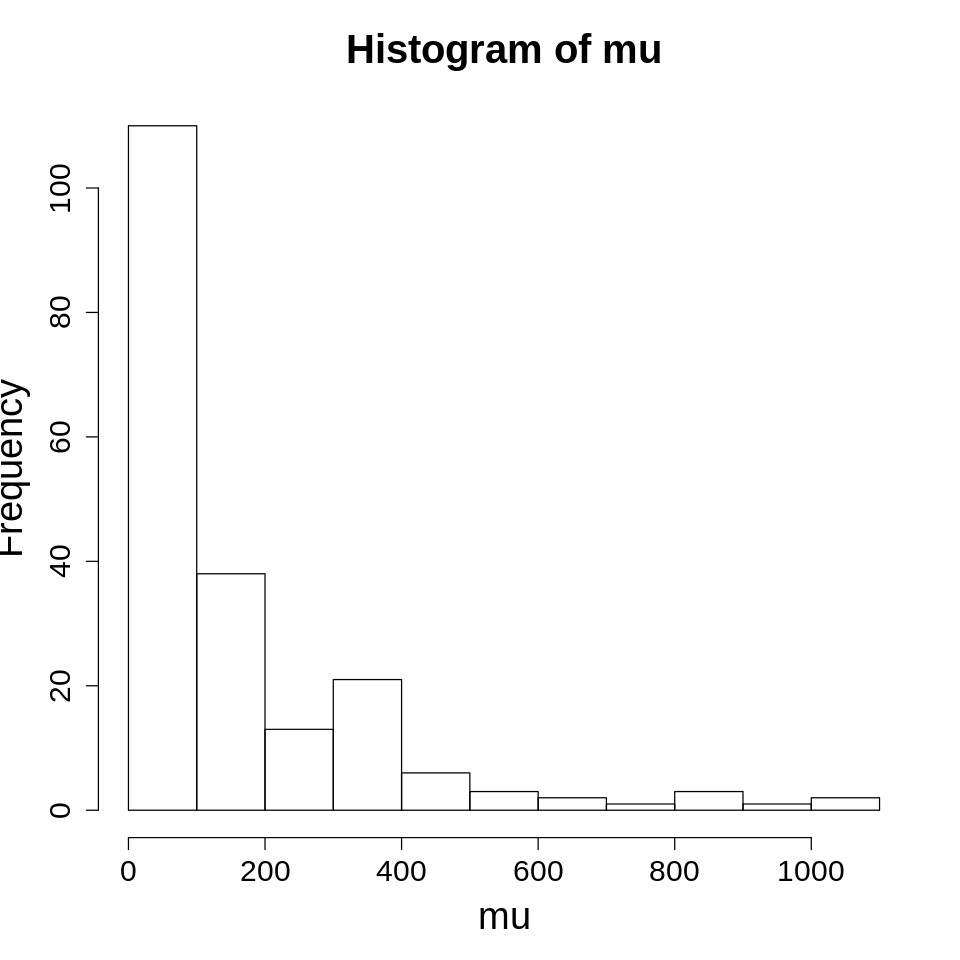

In [162]:
options(repr.plot.width = 8, repr.plot.height = 8)
beta1 = 5
log_mu = with(d, beta1 + sin(0.5*x1^2) - as.integer(x2) + as.integer(x3))
mu = exp(log_mu)
hist(mu, cex.axis=1.5, cex.lab=1.9, cex.main=2)
d$y = rpois(n, mu) #rnorm(n, mu, 0.1) # rpois(n, mu)

* Plot relations betweem the response and the predictor variables.

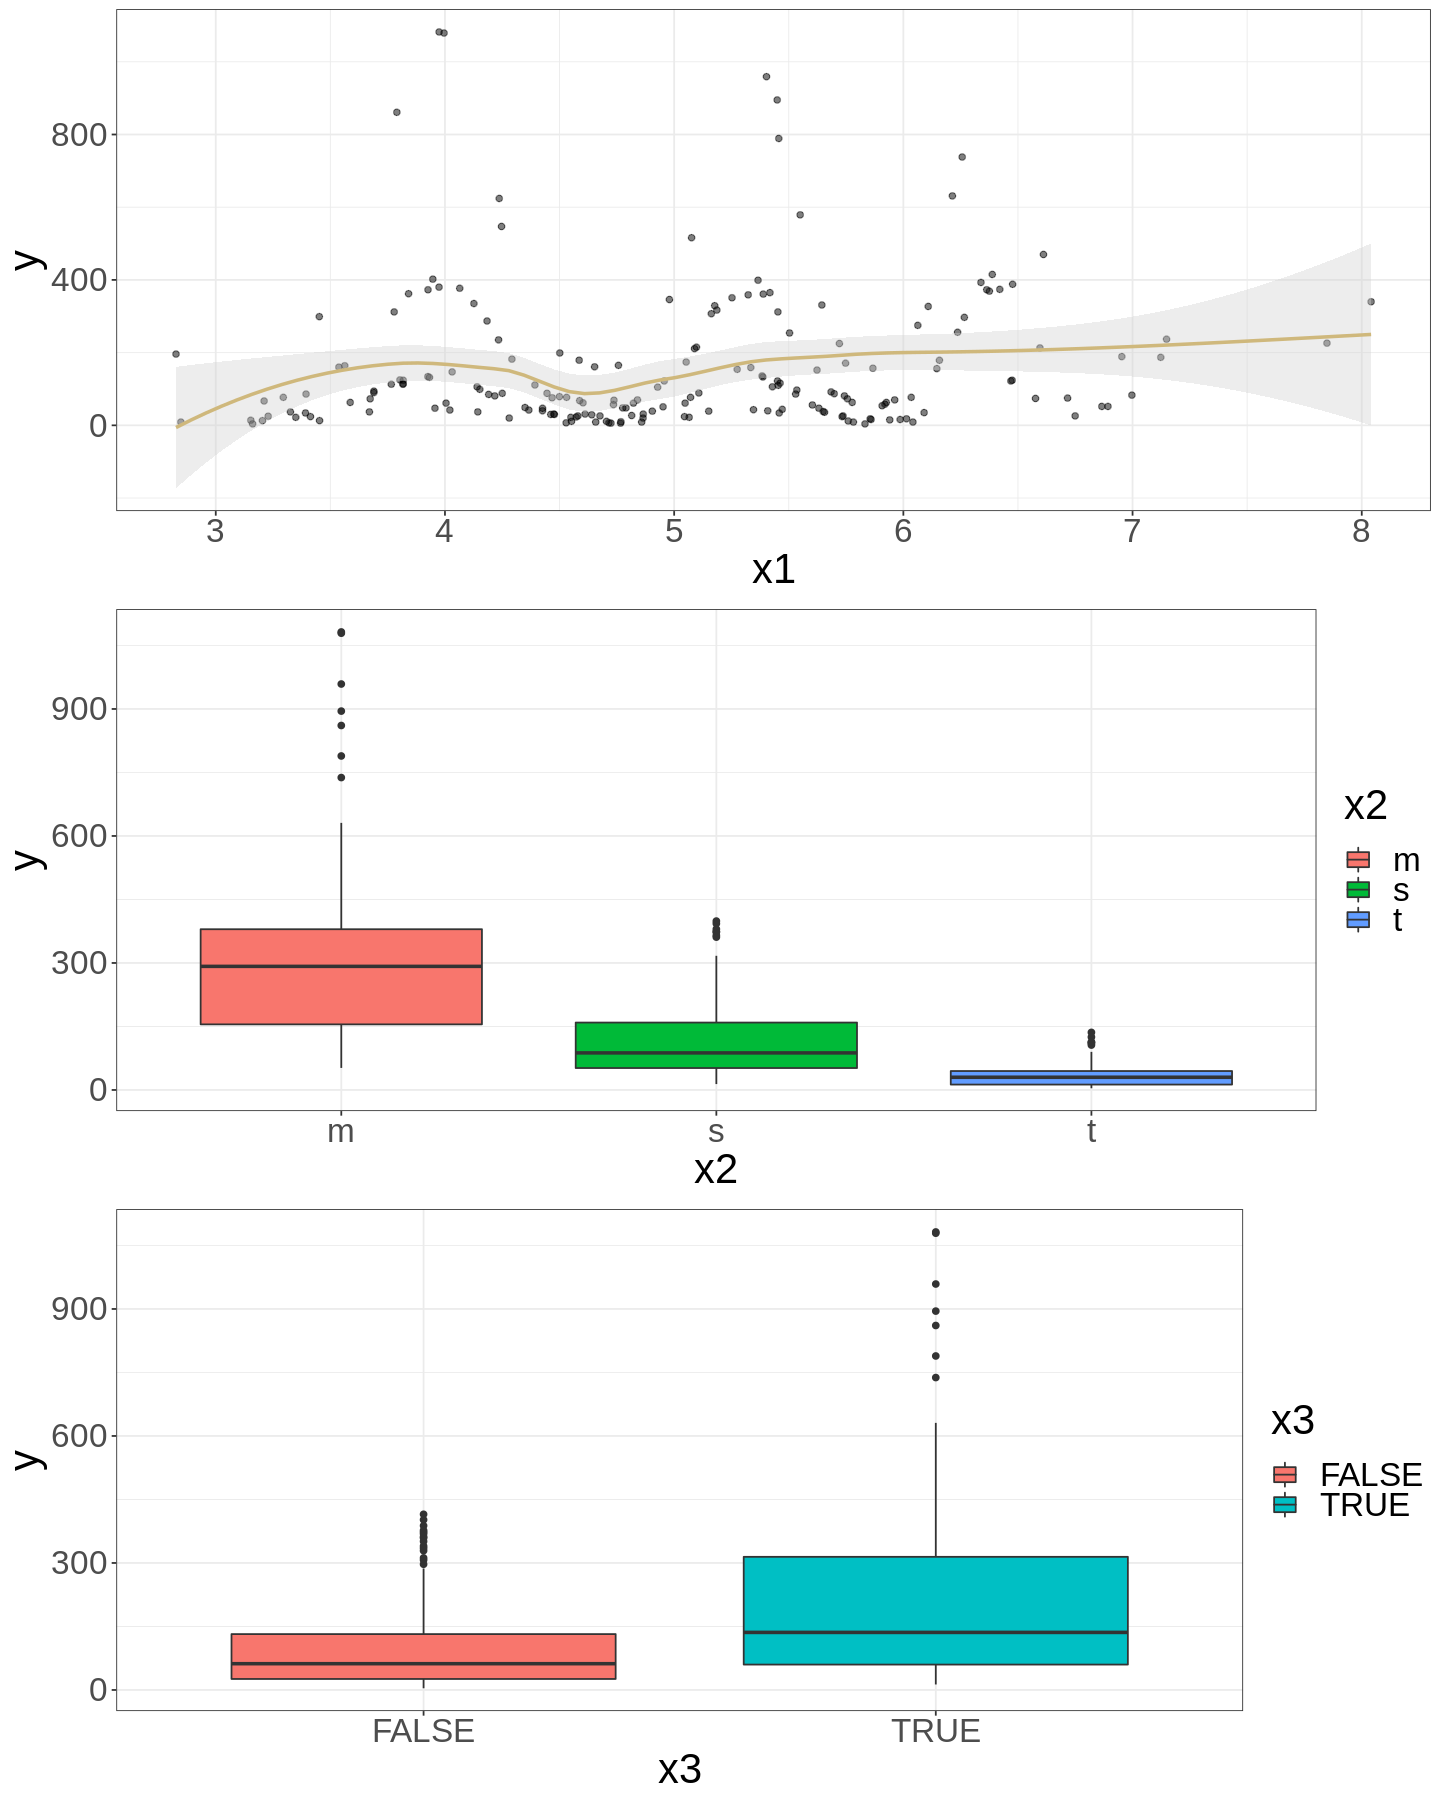

In [166]:
library(gridExtra)
options(repr.plot.width = 12, repr.plot.height = 15)

plot.relation <- function(d, x, y = 'y', type='scatter') {
    p <- ggplot(d, aes_string(x=x, y=y))
    if (type == 'scatter') {
        p <- p + geom_point(alpha = 0.5) +
                 geom_smooth(method = "loess", formula = y ~ x, color = "#CFB87C", fill = "lightgrey")
    } else if (type == 'box') {
        p <- p + geom_boxplot(aes_string(fill=x))
    }                
    p <- p + theme_bw() + 
             theme(text=element_text(size=25))
    p
}


grid.arrange(
    plot.relation(d, 'x1'),
    plot.relation(d, 'x2', type='box'),
    plot.relation(d, 'x3', type='box')
)

* Finally, let's split the data into a training (`train_sim`) and test (`test_sim`) set.

In [136]:
set.seed(11)
n_train = floor(0.8 * nrow(d))
index = sample(seq_len(nrow(d)), size = n_train)

train_sim = d[index, ]
test_sim = d[-index, ]
dim(train_sim)
dim(test_sim)

[1] 160   4

[1] 40  4

### 1. (b) Other Regression Models

Before jumping straight into GAMs, let's test if other regression models work. What about a regular linear regression model with ordinary least squares, and a generalized linear model for Poisson regression?

First fit a linear regression model to your `train_sim` data. We know that all of the predictors were used to make the response, but are they all significant in the linear regression model? Explain why this may be.

Then fit a Generalize Linear Model (GLM) to the `train_sim` data. Plot three diagnostic plots for your GLM:

1. Residual vs. log(Fitted Values)
2. QQPlot of the Residuals
3. Actual Values vs. Fitted Values

Using these plots, determine whether this model is a good fit for the data. Make sure to explain your conclusions and reasoning.

### Answer:

Let's define a few functions for plotting the scatter-plot (`plot.fit.act`) and qq-plots (`plot.qq`) between fitted vs. actual response values, these function can be reused for all the models. First let's start with linear regression model.

#### The Linear Regression Model (LM)


Call:
lm(formula = y ~ x1 + x2 + x3, data = train_sim)

Residuals:
    Min      1Q  Median      3Q     Max 
-215.38  -80.56   -7.15   57.65  707.43 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  256.073     59.541   4.301 3.00e-05 ***
x1            -1.154     10.967  -0.105    0.916    
x2s         -181.937     26.190  -6.947 9.70e-11 ***
x2t         -273.191     27.986  -9.762  < 2e-16 ***
x3TRUE       123.079     21.626   5.691 6.14e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 135.3 on 155 degrees of freedom
Multiple R-squared:  0.4585,	Adjusted R-squared:  0.4445 
F-statistic: 32.81 on 4 and 155 DF,  p-value: < 2.2e-16


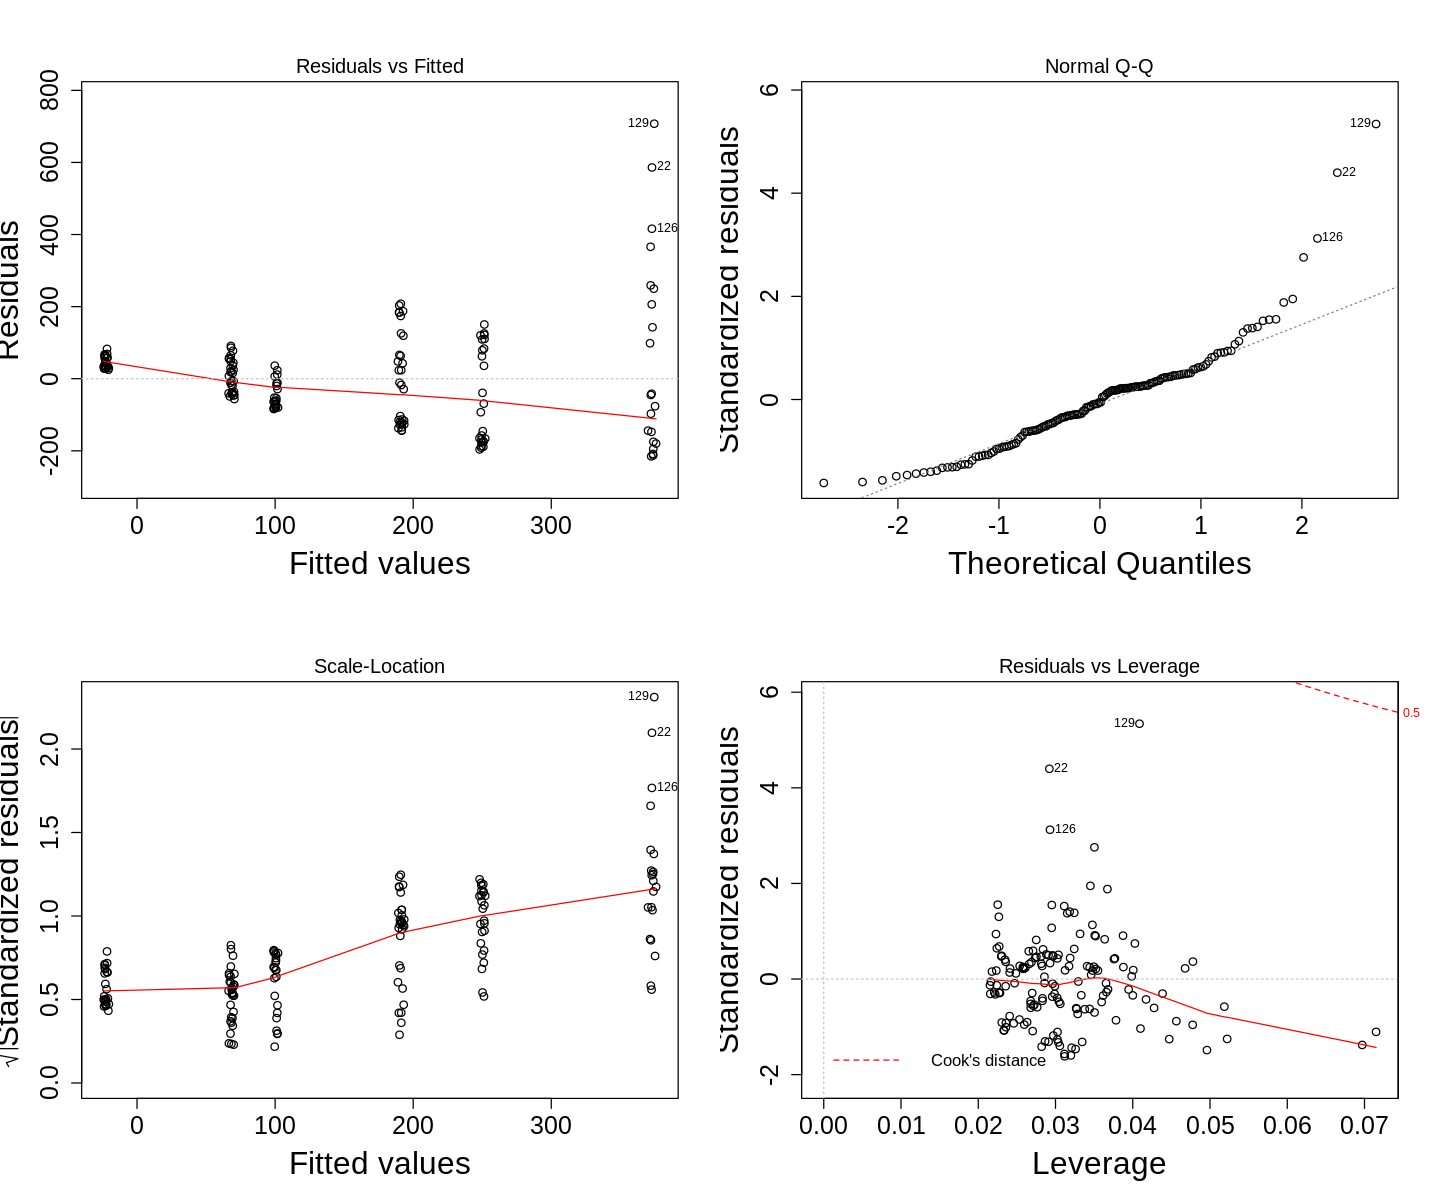

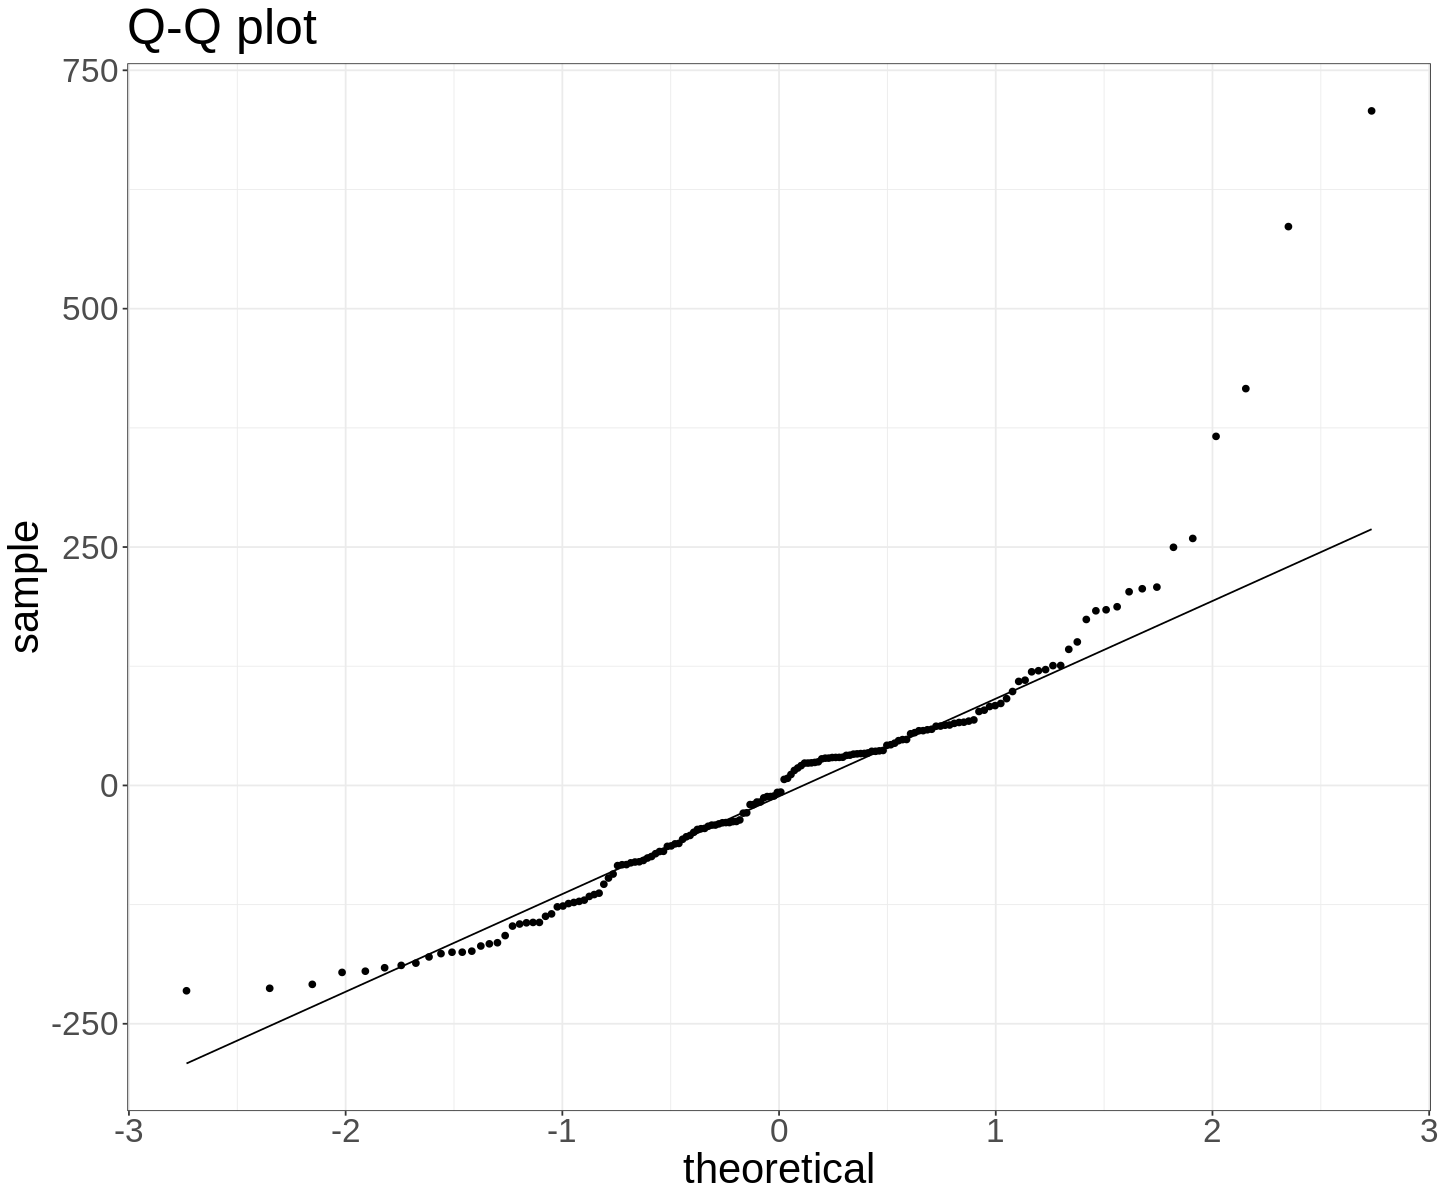

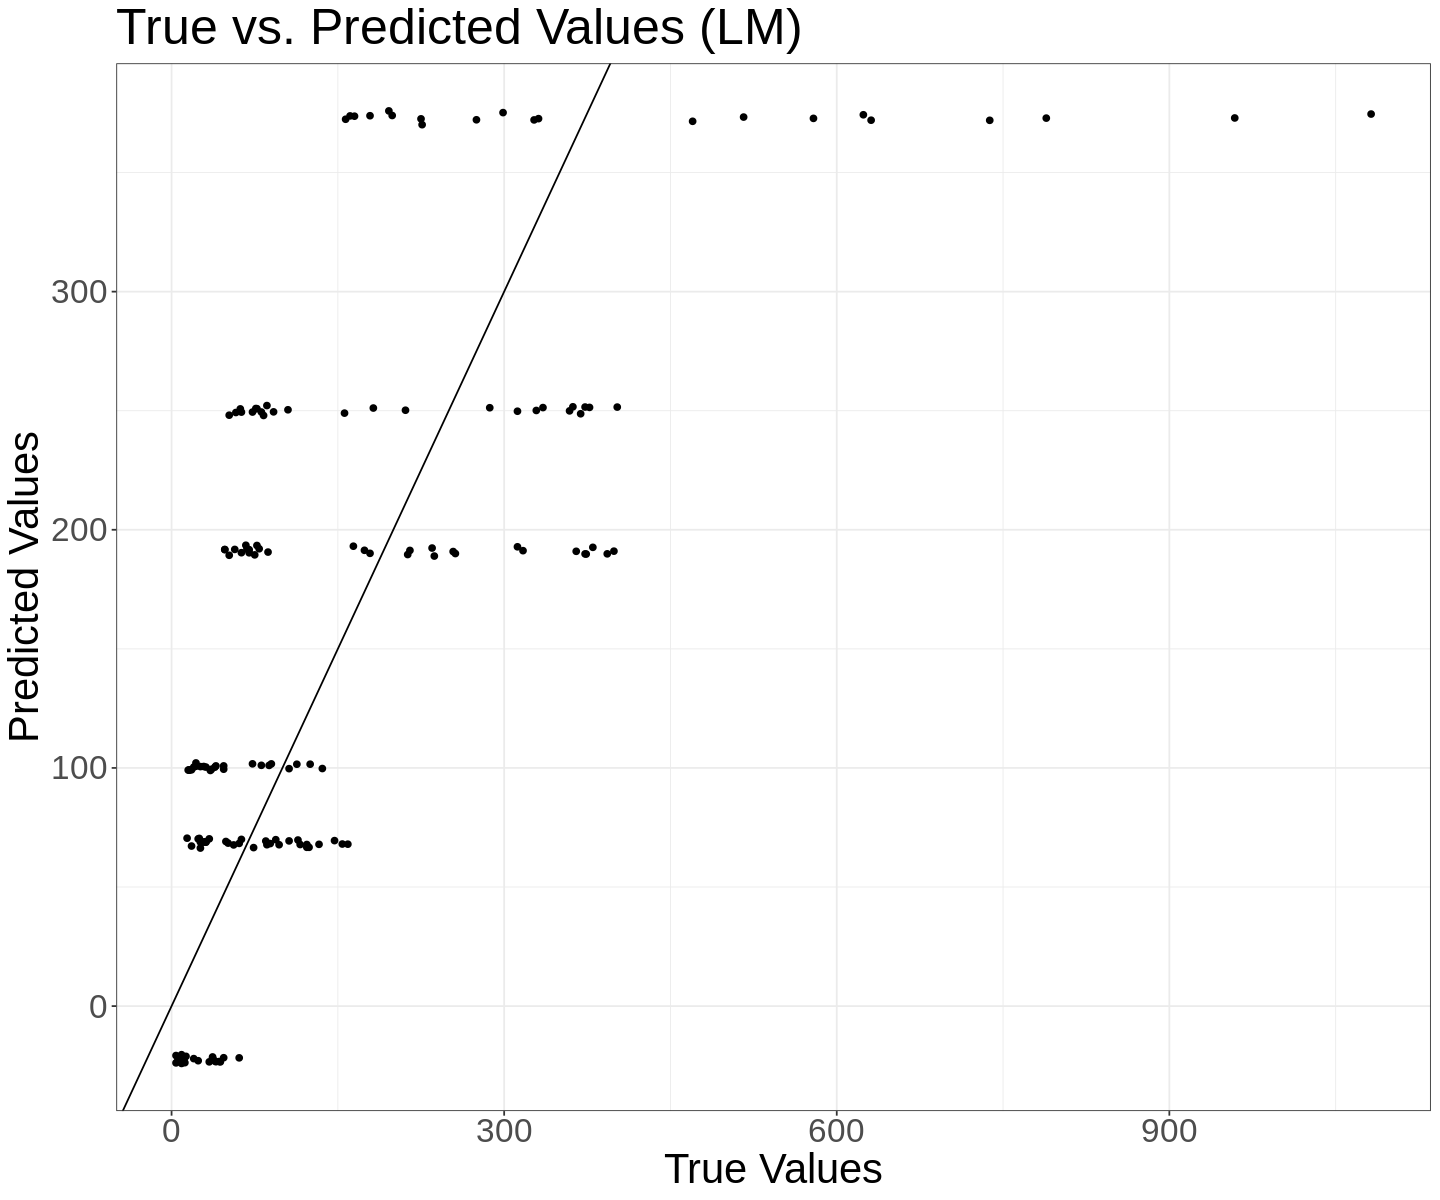

In [147]:
options(repr.plot.width = 12, repr.plot.height = 10)

# function to plot residual diagnostic
plot.res.diagnostic <- function(model) {
    par(mfrow=c(2,2))
    plot(model, cex.axis=1.5, cex.lab=1.9, cex.main=2)
    par(mfrow=c(1,1))    
}

# function to construct Q-Q plot
plot.qq <- function(res) {
    print(ggplot(data.frame(sample = res), aes(sample = sample)) + 
        stat_qq() + stat_qq_line() +
        theme_bw() + theme(text=element_text(size=25)) + ggtitle('Q-Q plot'))
}

# function to plot fitted vs. actual reponse values
plot.fit.act <- function(actual, pred, title) {
    p = ggplot() + geom_point(aes(actual, pred))
    p = p + geom_abline(intercept = 0, slope = 1)
    p = p + theme_bw()
    p = p + xlab("True Values") + ylab("Predicted Values")
    p = p + theme(text=element_text(size=25)) + ggtitle(title)
    print(p)
}

# Fit a LM model to the data
lm_sim = lm(y ~ x1 + x2 + x3, data = train_sim)
summary(lm_sim)

#residual plot
plot.res.diagnostic(lm_sim)

# qqplot
plot.qq(residuals(lm_sim))

#fitted vs actual
plot.fit.act(train_sim$y, predict(lm_sim), "True vs. Predicted Values (LM)")

#### Results of LM

* As can be seen from the below result, all variables but the $x_1$ variable are statistically significant predictors (with very low `p-value`s). It makes sense, since the response `y` depends **non-linearly** on the predictor *x_1* that linear regression can't model.
* From the summary, we can see that the goodness of fit of the model $R^2$ is quite low $0.4585$, adjusted $R^2$ is even lower $0.4445$. The diagnostic plot, the QQ plot and the fitted vs actual plot indicate that the model is likely not a good fit.

#### The Generalized Linear Regression Model (GLM) - The Poisson Regression Model


Call:
glm(formula = y ~ x1 + x2 + x3, family = "poisson", data = train_sim)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-15.632   -6.834   -2.230    4.558   25.301  

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)  5.291407   0.033285 158.970   <2e-16 ***
x1          -0.007711   0.006163  -1.251    0.211    
x2s         -0.896395   0.013910 -64.441   <2e-16 ***
x2t         -2.150740   0.025023 -85.951   <2e-16 ***
x3TRUE       0.844048   0.013818  61.085   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 26277  on 159  degrees of freedom
Residual deviance: 10082  on 155  degrees of freedom
AIC: 11085

Number of Fisher Scoring iterations: 5


[1] "McFadden' R^2"


[1] 0.6163283

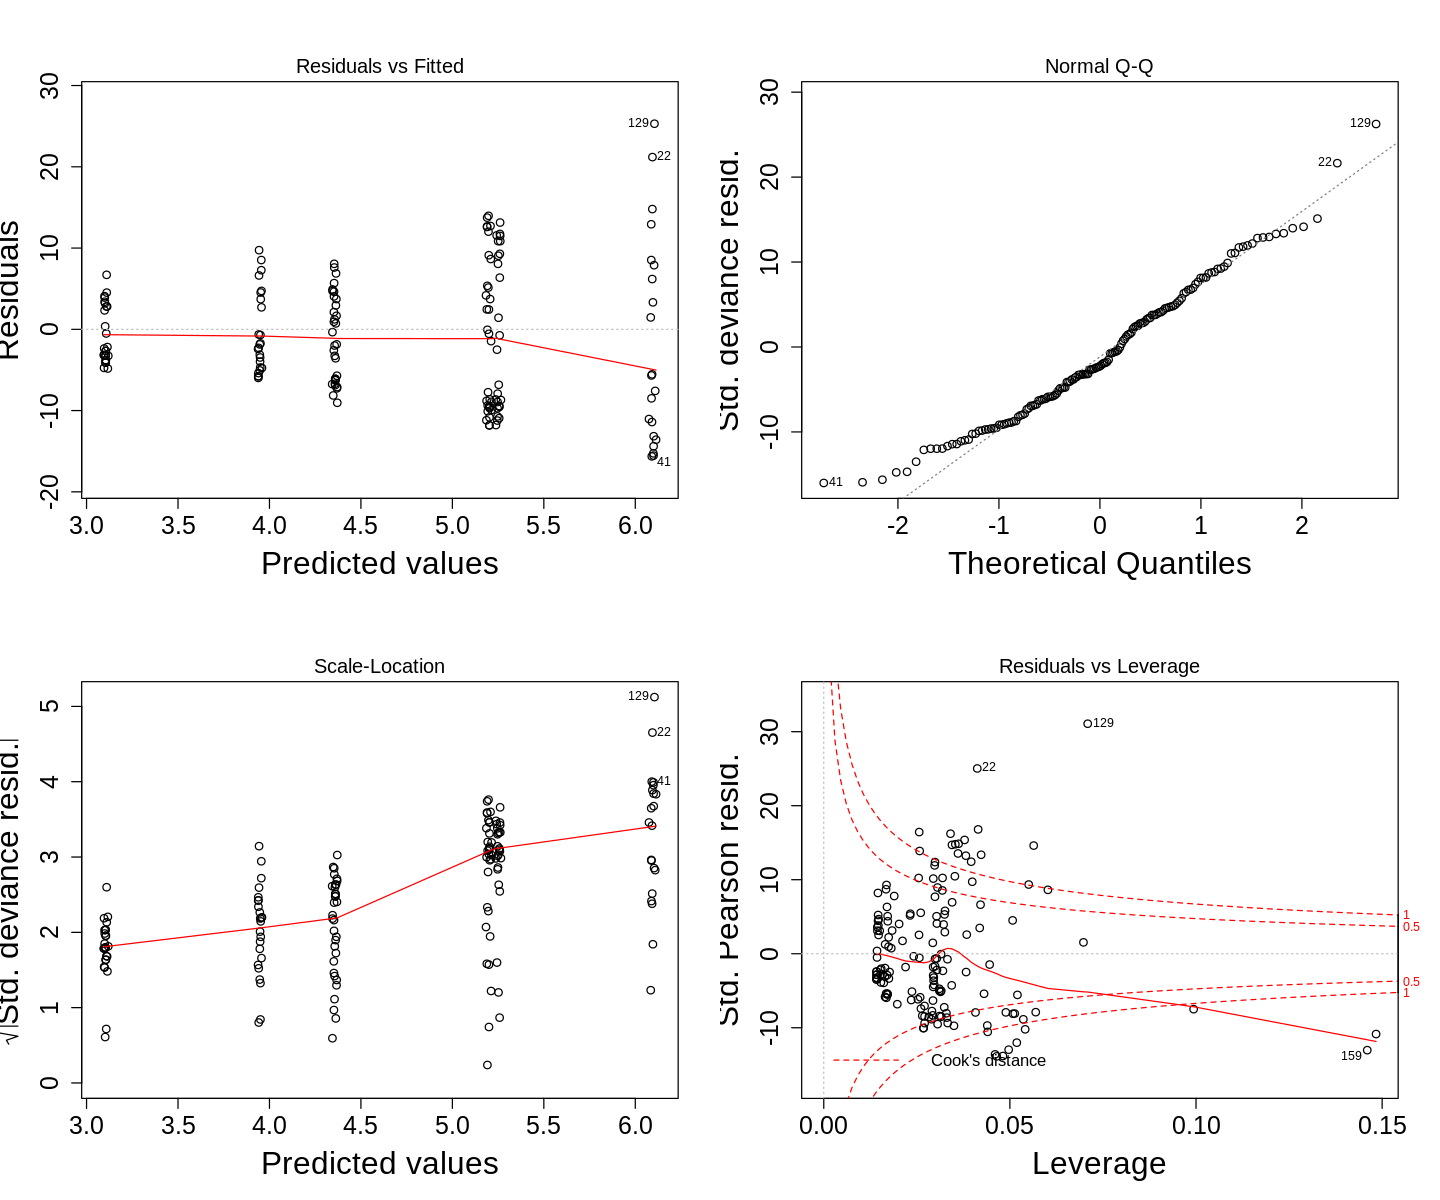

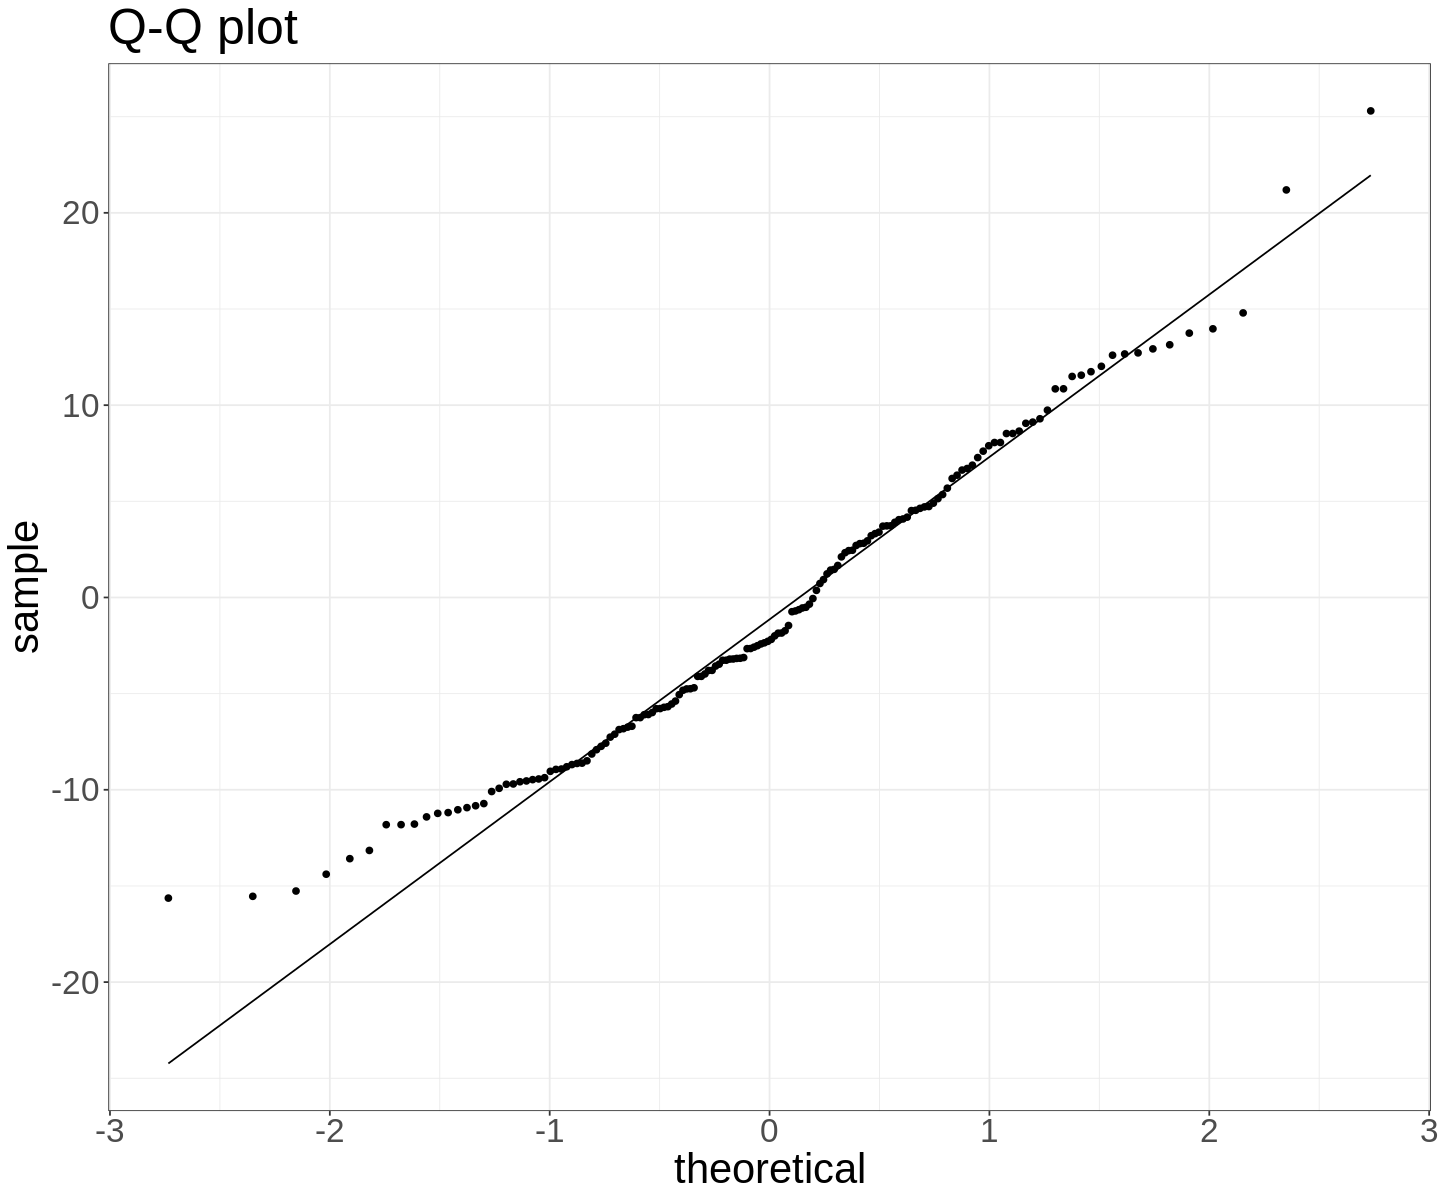

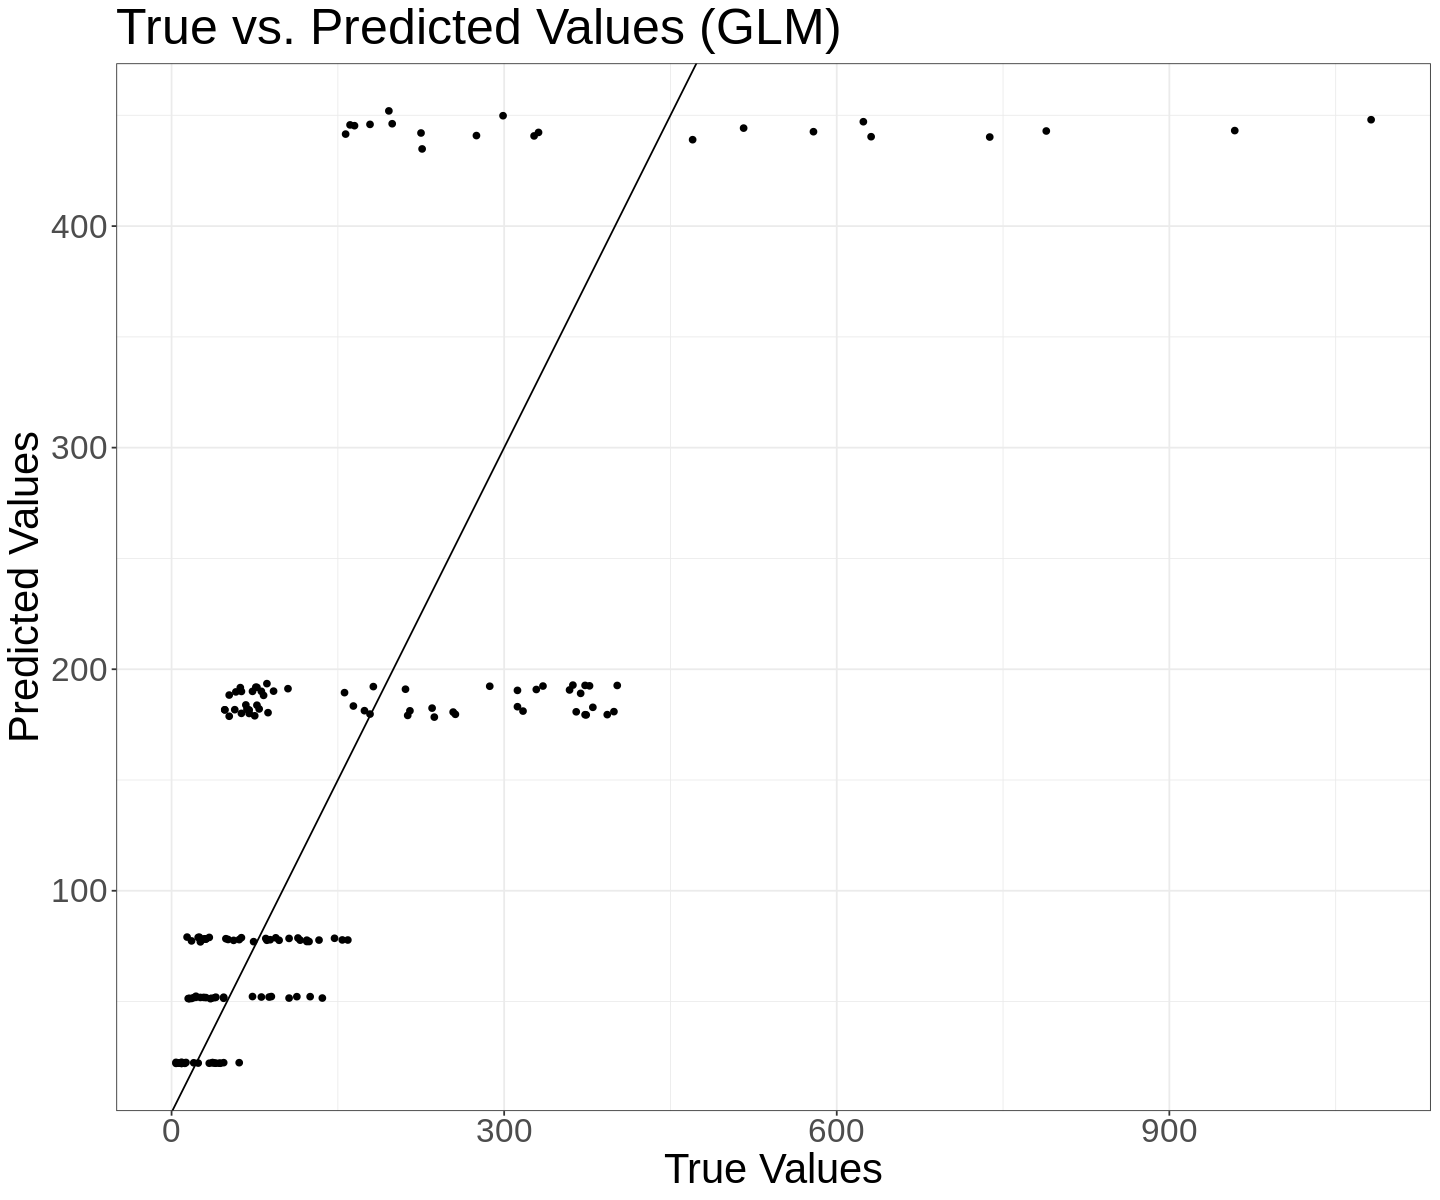

In [148]:
options(repr.plot.width = 12, repr.plot.height = 10)
# Fit a GLM model to the data
#train_sim$y = round(train_sim$y) # poisson expects integer (count) as response
glm_sim = glm(y ~ x1 + x2 + x3, data = train_sim, family = 'poisson')
summary(glm_sim)
#calculate McFadden's R-squared for GLM
print('McFadden\' R^2')
with(summary(glm_sim), 1 - deviance/null.deviance)

# Create the three specified plots

#residual plot
plot.res.diagnostic(glm_sim)

# qqplot
plot.qq(residuals(glm_sim))

#fitted vs actual
plot.fit.act(train_sim$y, predict(glm_sim, type='response'), "True vs. Predicted Values (GLM)")

#### Results of GLM

* As can be seen from the model summary, again, all variables except $x_1$ are significant predictor of the response `y`. Since the GLM could not capture the non-linear relation between `x1` and `y`, this is quite expected, as is supported by the diagnostic, QQ and actual-vs-fitted plots, the GLM still is not a very good fit.
* However, as per the nature of simulated data, we can see that poisson regression is a better fit than LM, with McFadden R^2 being $\approx 0.616$, a considerable improvement over the previous linar regression model.

### 1. (c) Looking for those GAMs

Now, it's time to see how a generalized additive model (GAM) performs! Fit a GAM to the data. Construct the same three plots for your GAM model. Do these plots look better than those of the GLM?

### Answer:

Now, let's fit a **GAM** model by having the predictor `x1` corresponding to the **nonparametric** smooth term (since there is a nonlinear relationship between `x1` and `y`), while letting all the other predictors correspond to the **parametric** linear forms.


Family: poisson 
Link function: log 

Formula:
y ~ s(x1) + x2 + x3

Parametric coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  4.93877    0.01378  358.28   <2e-16 ***
x2s         -0.95061    0.01450  -65.54   <2e-16 ***
x2t         -2.04183    0.02527  -80.79   <2e-16 ***
x3TRUE       1.01055    0.01423   71.02   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
        edf Ref.df Chi.sq p-value    
s(x1) 8.997      9   7788  <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

R-sq.(adj) =  0.966   Deviance explained = 96.1%
UBRE = 5.5772  Scale est. = 1         n = 160

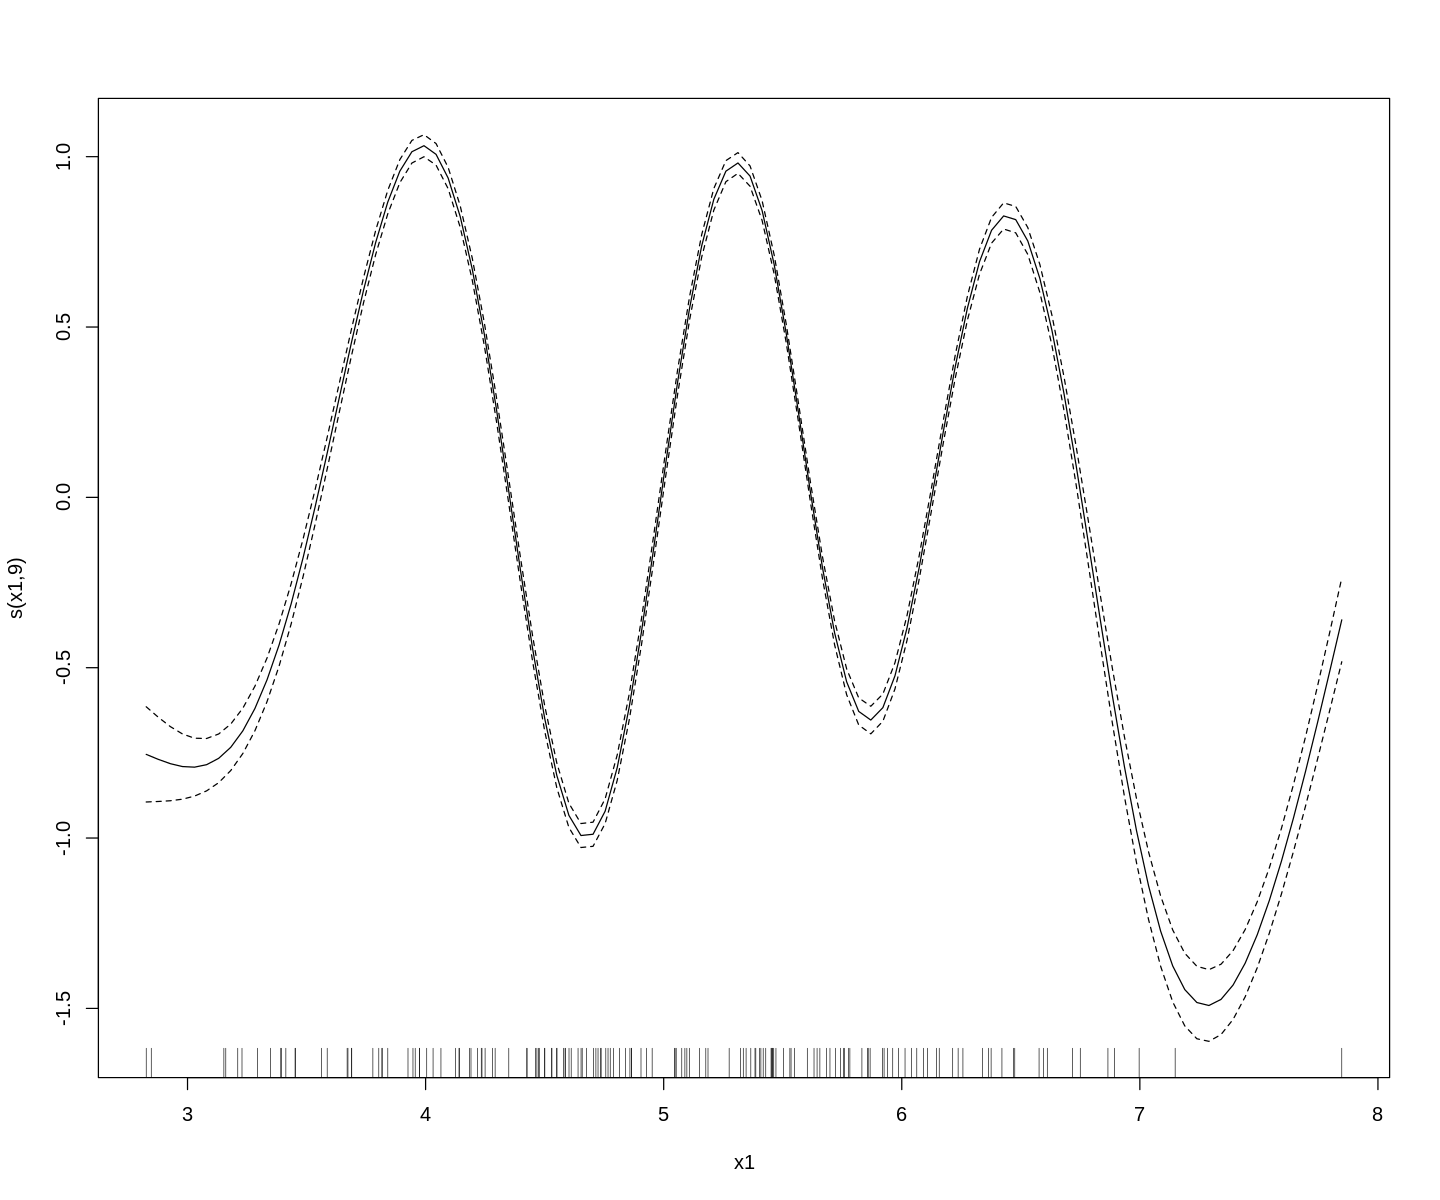

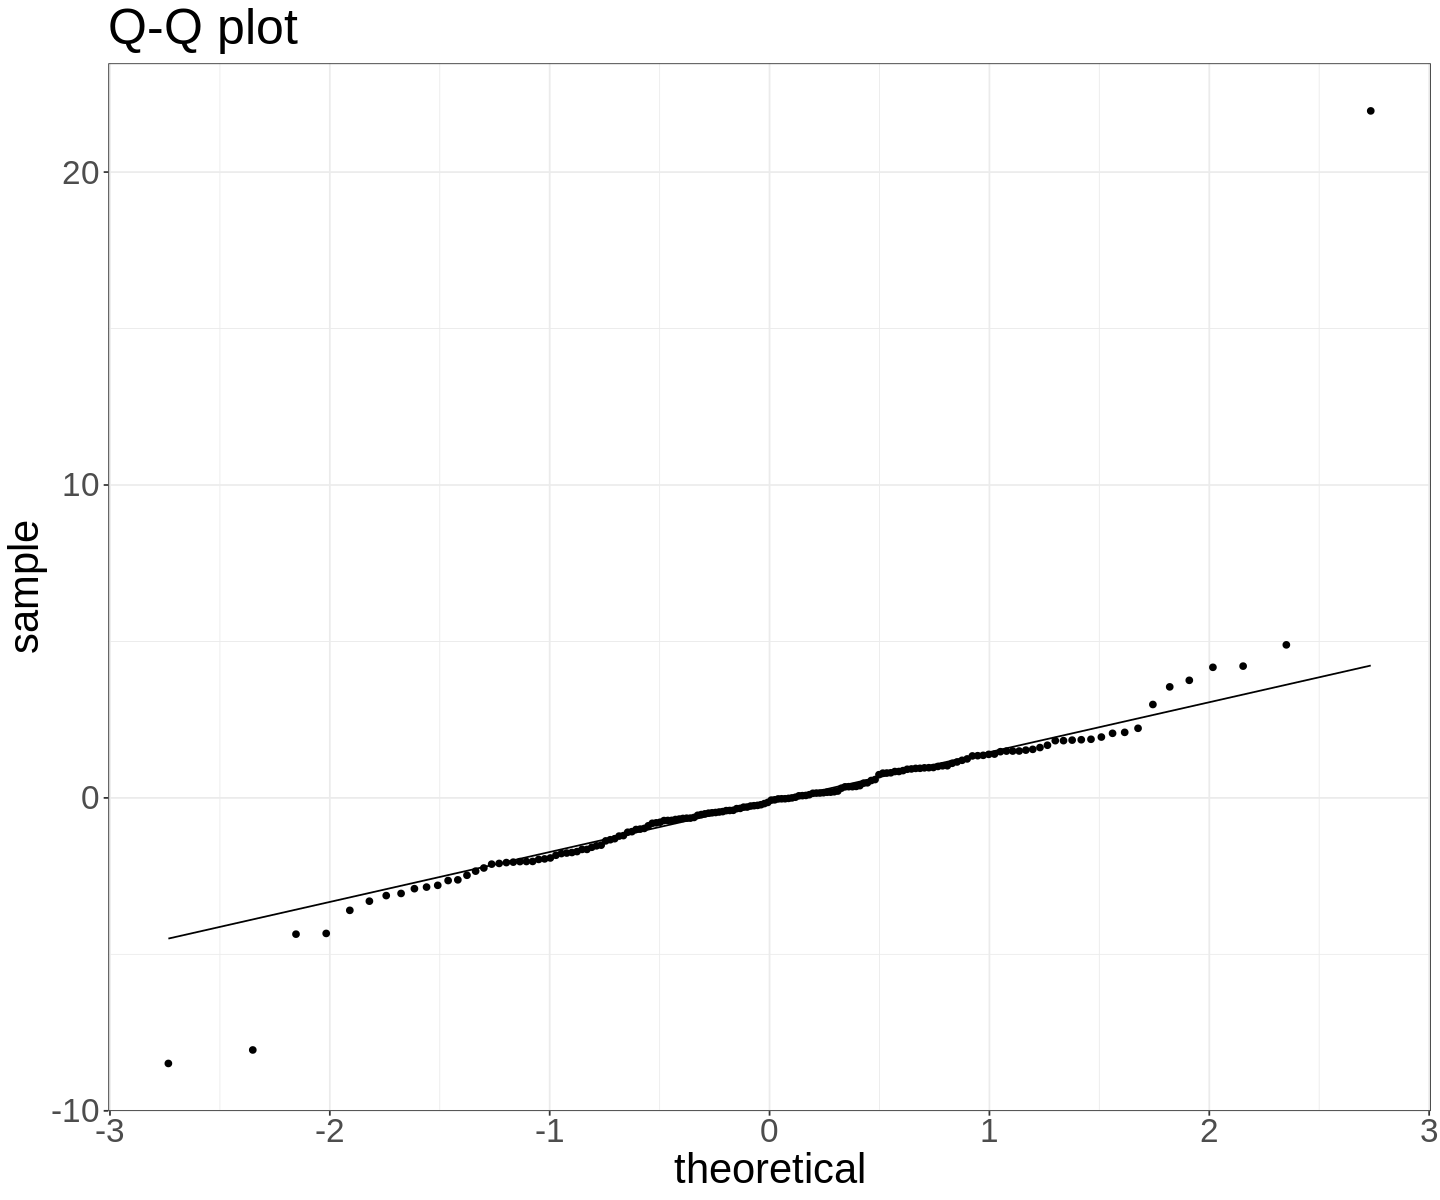

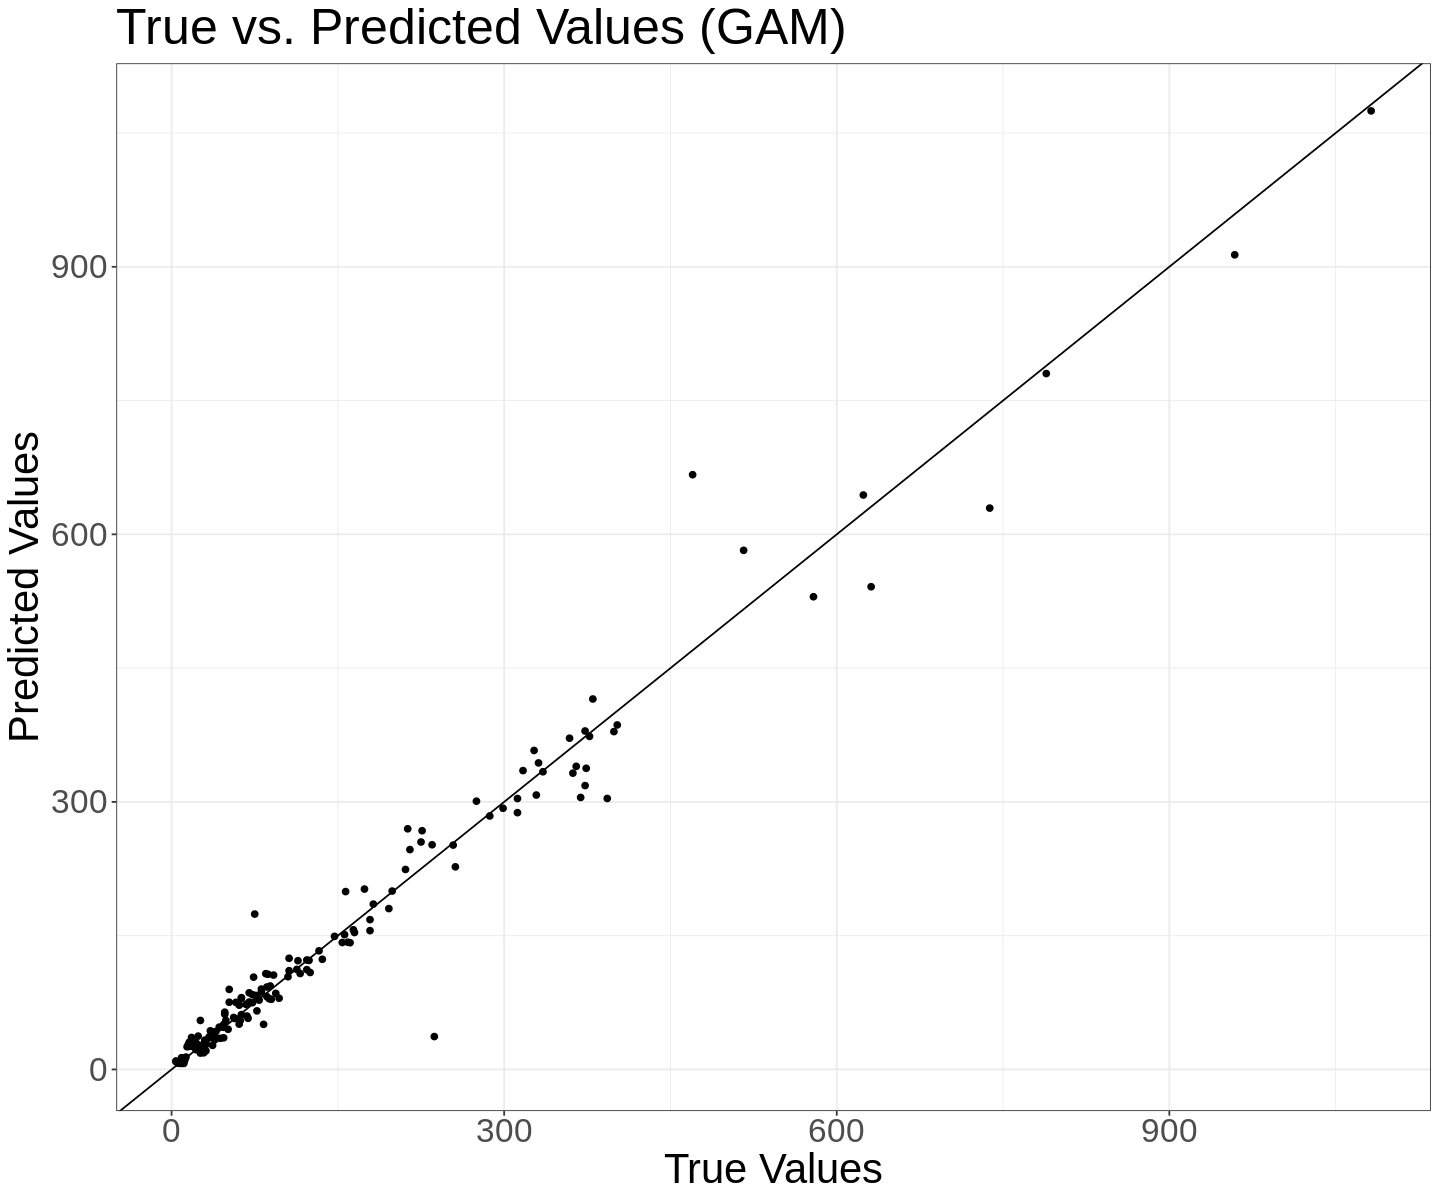

In [151]:
# Fit a GAM model to the data
library(mgcv)
gam_sim = gam(y ~ s(x1) + x2 + x3, data = train_sim, family = poisson)
summary(gam_sim)

# Construct the three specified plots

#residual vs fitted 
plot(gam_sim)

## qqplot
plot.qq(residuals(gam_sim))

#fitted vs actual
plot.fit.act(train_sim$y, predict(gam_sim, type='response'), "True vs. Predicted Values (GAM)")

#### Result of GAM

* As can be seen from the actual-vs-fitted plot, **GAM** seems to be a significant improvement over **GLM**.
* All the predictors have become statistically significant now, as can be seen from the parameteric part of the summary table.
* The adjusted $R^2 =  0.966$ and the **Deviance** explained = $96.1\%$ from the model summary table implies that the model is a very good fit.
* From the nonparametric part of the summary table, the effective degrees of freedom (**edf**) of the smoothed term is $8.997$, which is much higher than $1$, indicating that this term should be smoothed, and should not enter the model linearly.

### 1. (d) Interpreting GAMs

We made a GAM model! However GAMs are harder to interpret than regular linear regression models. How do we determine if a GAM model was necesary? Or, in other words, how do we determine if our predictors have a linear relationship with the response?

Use the `plot.gam()` function in the mgcv library to plot the relationship between `y` and `x1`. Recall that $x_1$ entered our model as $\sin(0.5x_{i,1}^2)$, and we plotted that relationship in **1.(a)**. Does your plot confirm this relationship?

#### Answer:

As can be seen from the marginal plot output by `plot.gam()` function below, it is not possible to fit a straight line and the predictor $x_1$ should not enter linearly in the model, this is confirmed by the **edf** (effective degrees of freedom) $=8.997$ obtained from the model summary, which is much higher than $1$.  

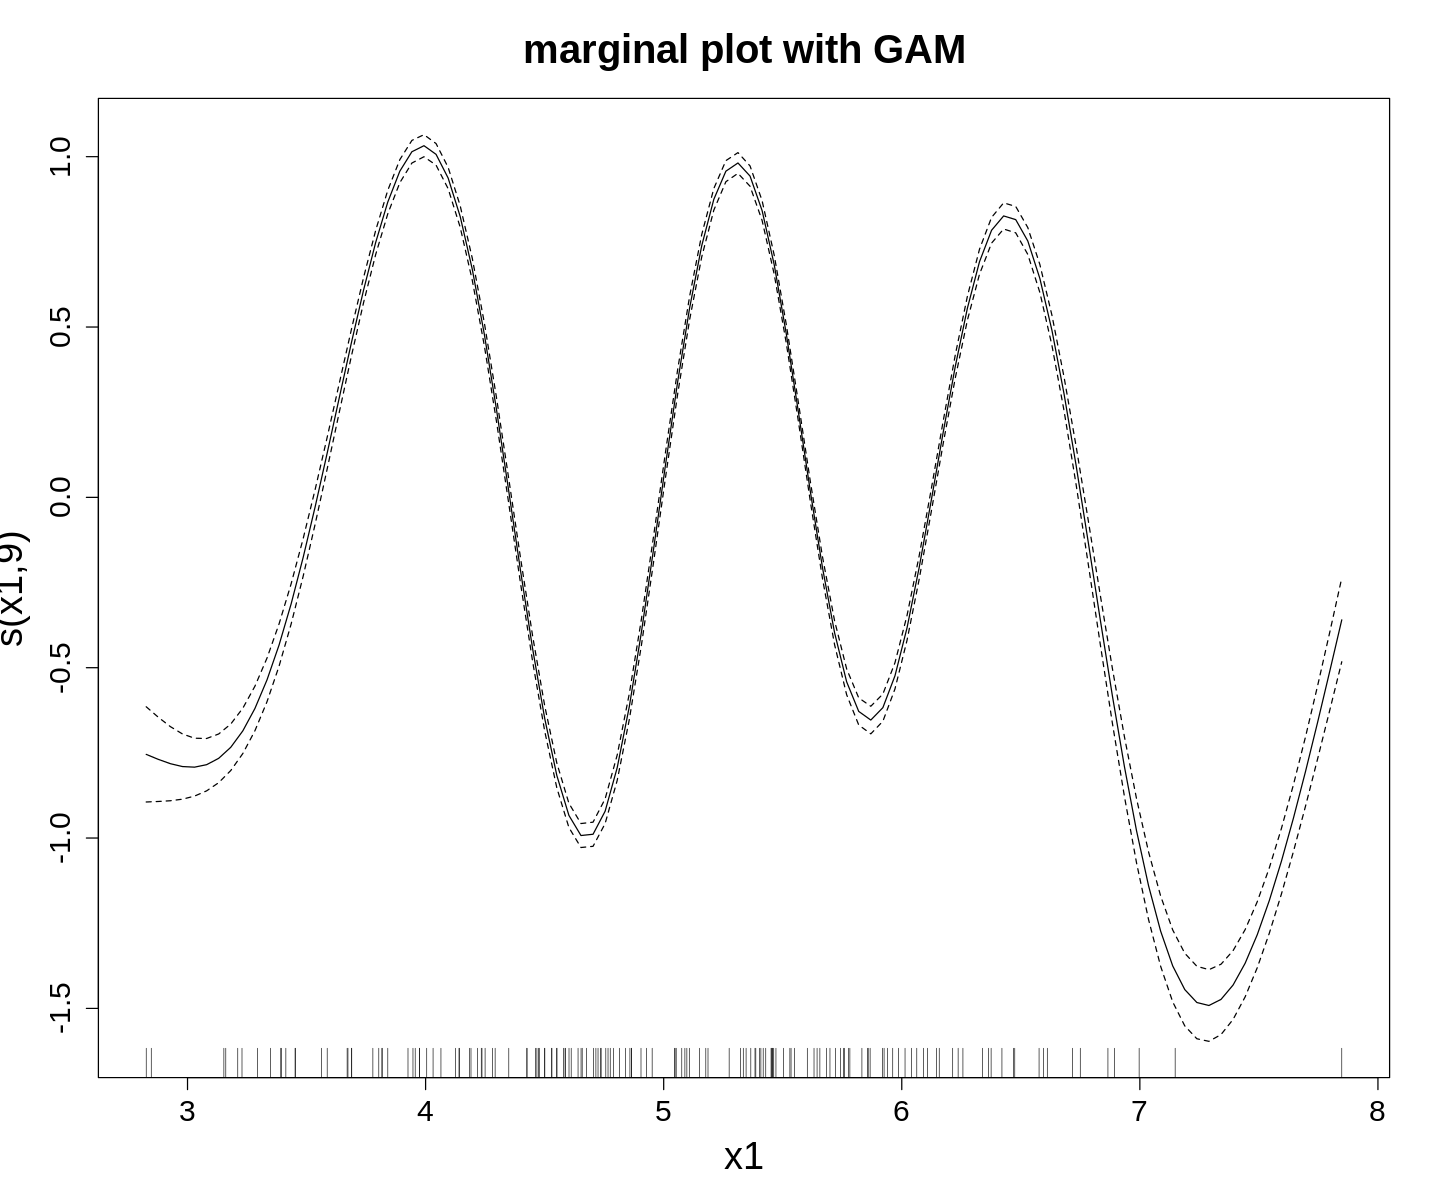

In [140]:
plot.gam(gam_sim, cex.axis=1.5, cex.lab=1.9, cex.main=2, main='marginal plot with GAM')

### 1.(e) Model comparison

Compute the mean squared prediction error (MSPE) for each of the three models above (regression model, GLM, and GAM). State which model performs based according to this metric.

Remember, the MSPE is given by 

\begin{align*}
MSPE = \frac{1}{k}\sum^k_{i=1}\left(y^\star_i - \widehat{y}^\star_i \right)^2 
\end{align*}

where $y^\star_i$ are the observed response values in the test set and $\widehat{y}^\star_i$ are the predicted values for the test set (using the model fit on the training set).

### Answer:

As per the **MSPE** value computed on the **test** dataset below, the **GAM** model performs the best with the lowest **MSPE**, much lesser than the other models. The next model in terms of performance is the **GLM** model, which performs slightly better than the **LM** model.

In [152]:
#mspe for lm
mspe_lm = mean((test_sim$y - predict(lm_sim, newdata=test_sim))^2)

#mspe for glm
mspe_glm = mean((test_sim$y - predict(glm_sim, newdata=test_sim, type='response'))^2)

# mspe for gam
mspe_gam = mean((test_sim$y - predict(gam_sim, newdata=test_sim, type = "response"))^2)

data.frame(mspe_lm, mspe_glm, mspe_gam)

mspe_lm,mspe_glm,mspe_gam
<dbl>,<dbl>,<dbl>
34773.72,30461.41,2413.963


# Problem 2 Additive models with the advertising data

The following dataset containts measurements related to the impact of three advertising medias on sales of a product, $P$. The variables are:

- `youtube`: the advertising budget allocated to YouTube. Measured in thousands of dollars;

- `facebook`: the advertising budget allocated to Facebook. Measured in thousands of dollars; and 

- `newspaper`: the advertising budget allocated to a local newspaper. Measured in thousands of dollars.

- `sales`: the value in the $i^{th}$ row of the sales column is a measurement of the sales (in thousands of units) for product $P$ for company $i$.

The advertising data treat "a company selling product $P$" as the statistical unit, and "all companies selling product $P$" as the population. We assume that the $n = 200$ companies in the dataset were chosen at random from the population (a strong assumption!).

First, we load the data, plot it, and split it into a training set (`train_marketing`) and a test set (`test_marketing`).

,youtube,facebook,newspaper,sales
,<dbl>,<dbl>,<dbl>,<dbl>
1,276.12,45.36,83.04,26.52
2,53.40,47.16,54.12,12.48
3,20.64,55.08,83.16,11.16
4,181.80,49.56,70.20,22.20
5,216.96,12.96,70.08,15.48
6,10.44,58.68,90.00,8.64


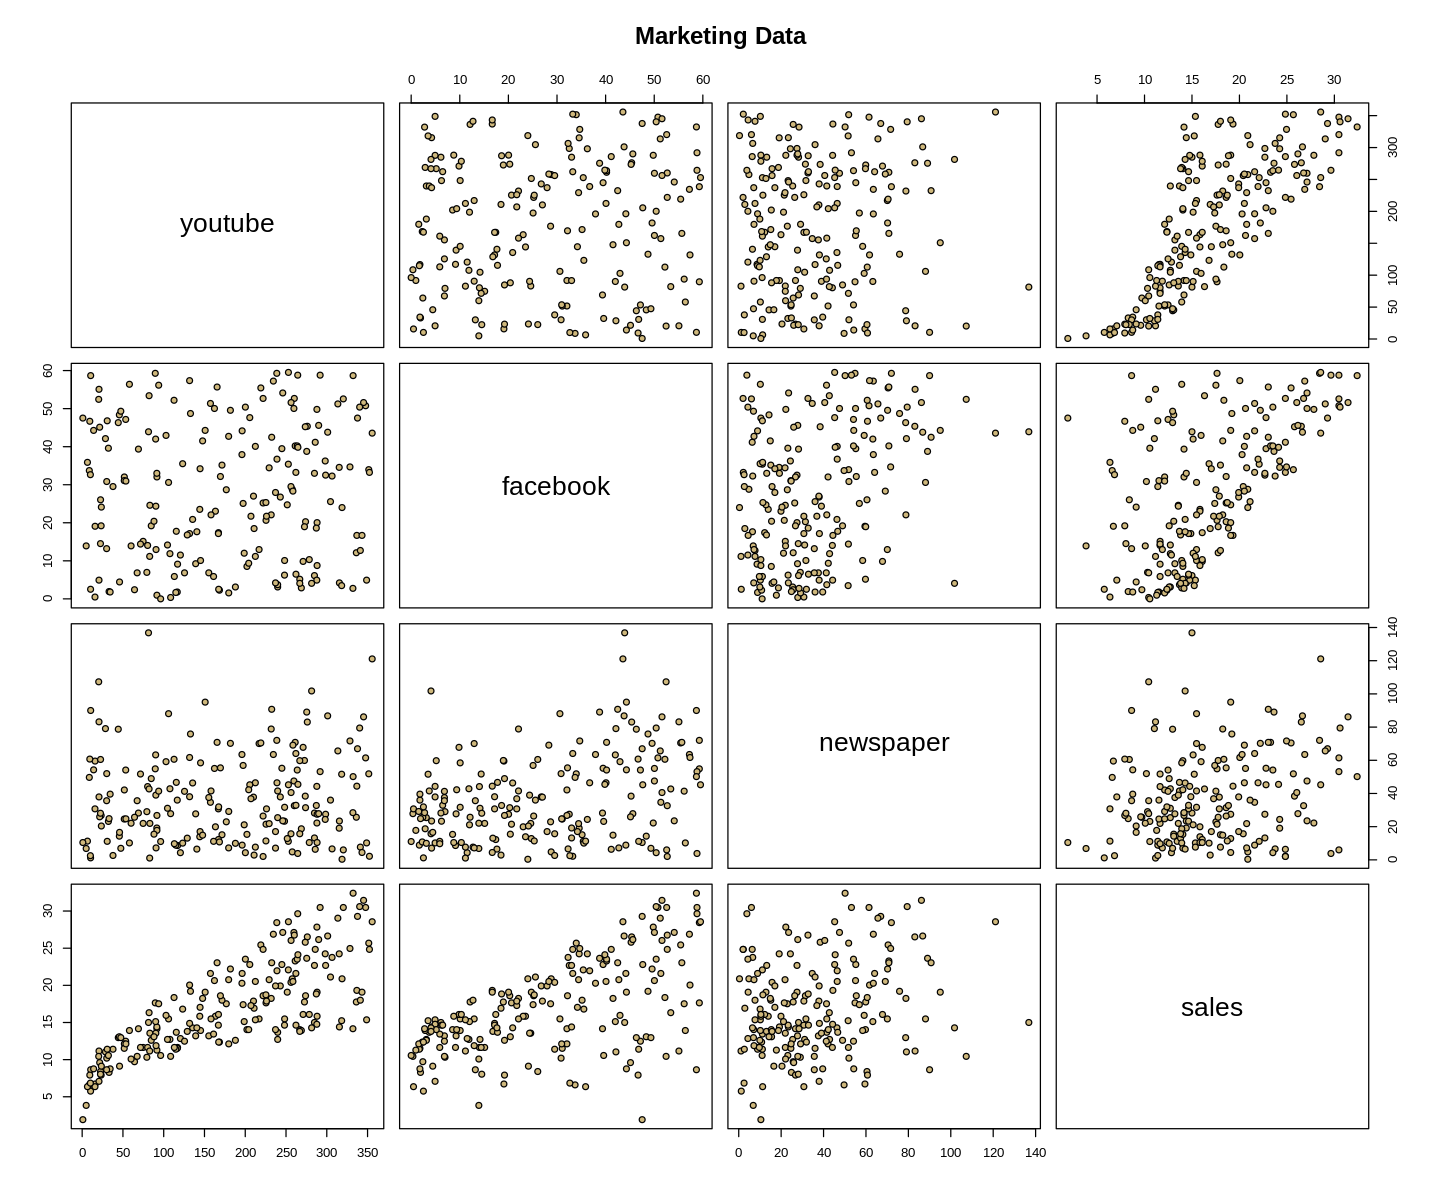

In [143]:
# Load in the data
marketing = read.csv("marketing.txt", sep = "")
head(marketing)
pairs(marketing, main = "Marketing Data", pch = 21, 
      bg = c("#CFB87C"))

In [144]:
set.seed(177) #set the random number generator seed.
n = floor(0.8 * nrow(marketing)) #find the number corresponding to 80% of the data
index = sample(seq_len(nrow(marketing)), size = n) #randomly sample indicies to be included in the training set

train_marketing = marketing[index, ] #set the training set to be the randomly sampled rows of the dataframe
test_marketing = marketing[-index, ] #set the testing set to be the remaining rows
dim(test_marketing) #check the dimensions
dim(train_marketing) #check the dimensions

[1] 40  4

[1] 160   4

**2.(a) Let's try a GAM on the marketing data!**

Note that the relationship between `sales` and `youtube` is nonlinear. This was a problem for us back in the first course in this specialization, when we modeled the data as if it were linear. In the last module, we focused on modeling the relationship between `sales` and `youtube`, omitting the other variables. Now it's time to include the additional predictors.

Using the `train_marketing` fit an additive model to the data and store it in `gam_marketing`. Produce the relevant added variable plots using `plot(gam_marketing)`. Comment on the fit of the model.


### Answer:

As can be seen from below, the **GAM** model with the predictor `youtube` as nonlinear smoothing term (to predict the response `sale`) fits quite well on the training data, with adjusted $R^2 = 0.929$ and $93.2\%$ residual deviance explained by the model. 


Family: gaussian 
Link function: identity 

Formula:
sales ~ s(youtube) + facebook + newspaper

Parametric coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 11.264013   0.279555  40.293   <2e-16 ***
facebook     0.186582   0.008530  21.874   <2e-16 ***
newspaper    0.004403   0.005811   0.758     0.45    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
           edf Ref.df     F p-value    
s(youtube) 5.9  7.047 202.1  <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

R-sq.(adj) =  0.929   Deviance explained = 93.2%
GCV = 2.9718  Scale est. = 2.8065    n = 160

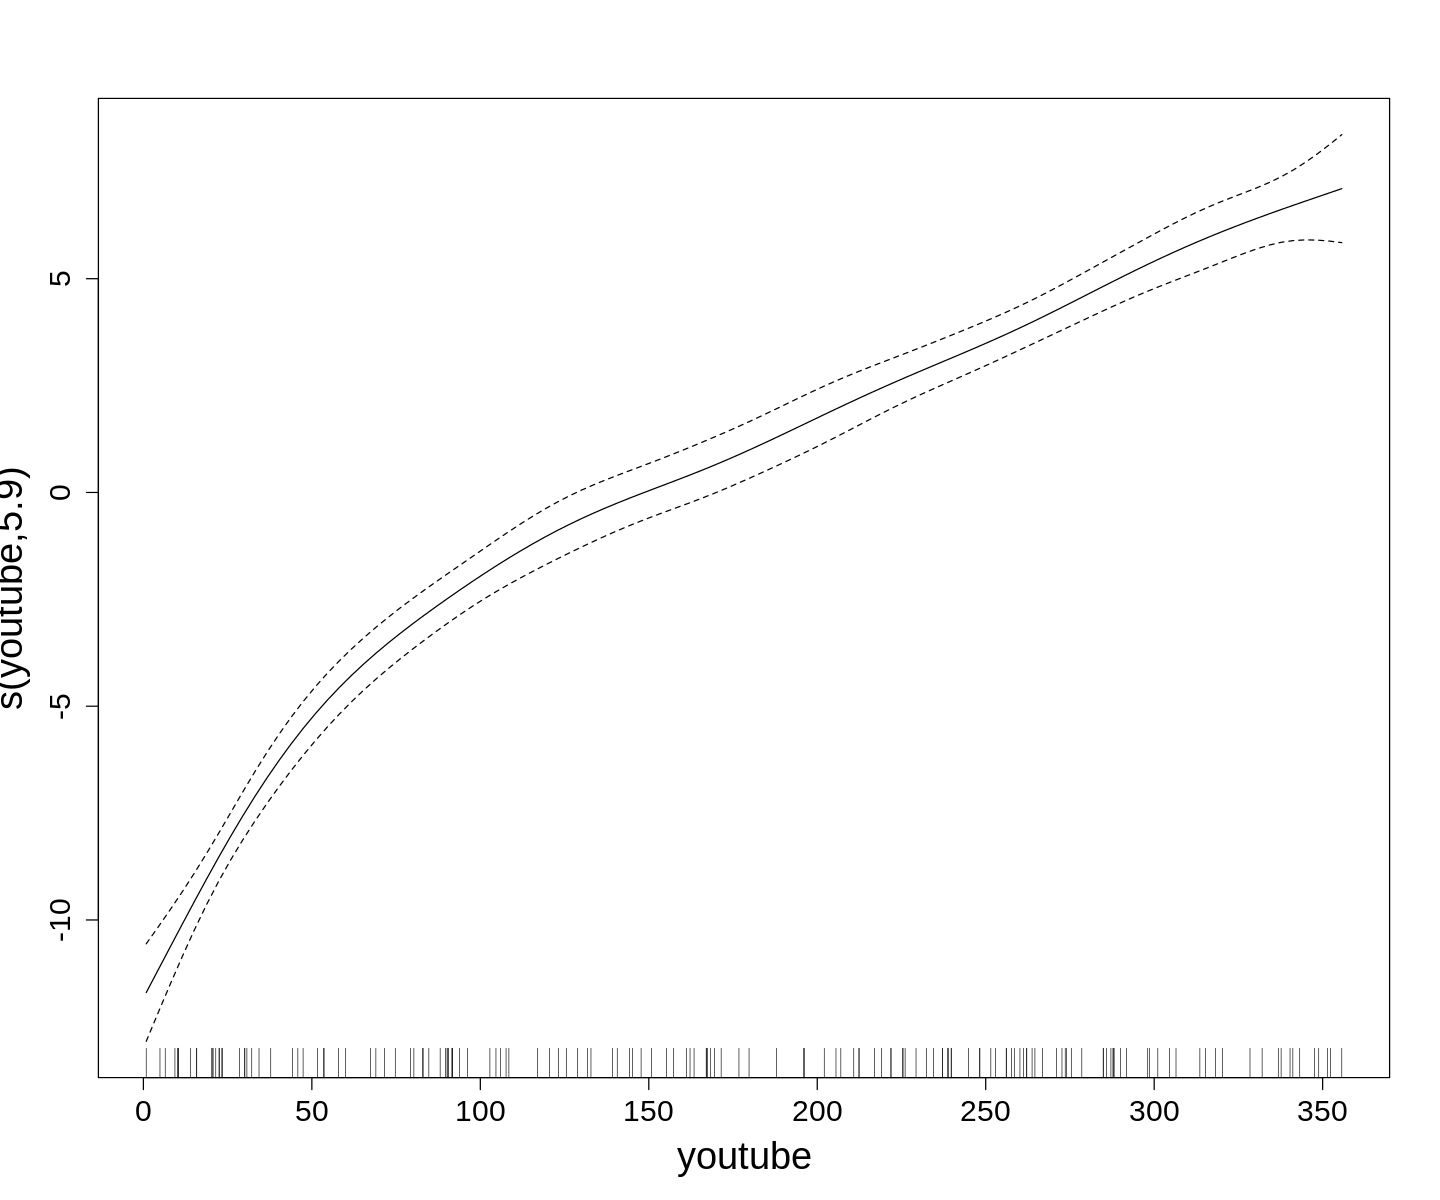

In [158]:
gam_marketing = gam(sales ~ s(youtube) + facebook + newspaper, data = train_marketing)
summary(gam_marketing)
plot(gam_marketing, cex.axis=1.5, cex.lab=1.9, cex.main=2)

**2.(b) Semiparametric modeling of the marketing data**

Refit the additive model based on your results from 2.(a). That is, if any predictors above should enter linearly, refit the model to reflect that. If any predictors are statistically insignificant, remove them from the model. Store your final model in `semiparametric_marketing`.

### Answer:

As can be seen from the summary of the above **GAM** model,

* The predctor `newsaper` is not statistically significant, so let's get rid of this predicotr from the model.
* The variable `youtube` has **edf** $= 5.29$, which is quite higher than $1$, so it should not enter the model linearly, as suppported by the above plot too, it will be difficult to fit a straight line inside the confidence region.
* From the initial response by predictor plot, it seems the predictor `facebook` can enter the model linearly.

Taking the above into account, let's fit the semiparametric model.

In [153]:
semiparametric_marketing = gam(sales ~ s(youtube) + facebook, data = train_marketing)
summary(semiparametric_marketing)


Family: gaussian 
Link function: identity 

Formula:
sales ~ s(youtube) + facebook

Parametric coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 11.352099   0.253895   44.71   <2e-16 ***
facebook     0.189085   0.007848   24.09   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
             edf Ref.df     F p-value    
s(youtube) 5.979  7.127 200.9  <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

R-sq.(adj) =  0.929   Deviance explained = 93.2%
GCV = 2.9438  Scale est. = 2.797     n = 160

As can be seen from the above model summary, the model adjusted $R^2$ remains the same ($0.929$) and same holds for the explained model deviance.

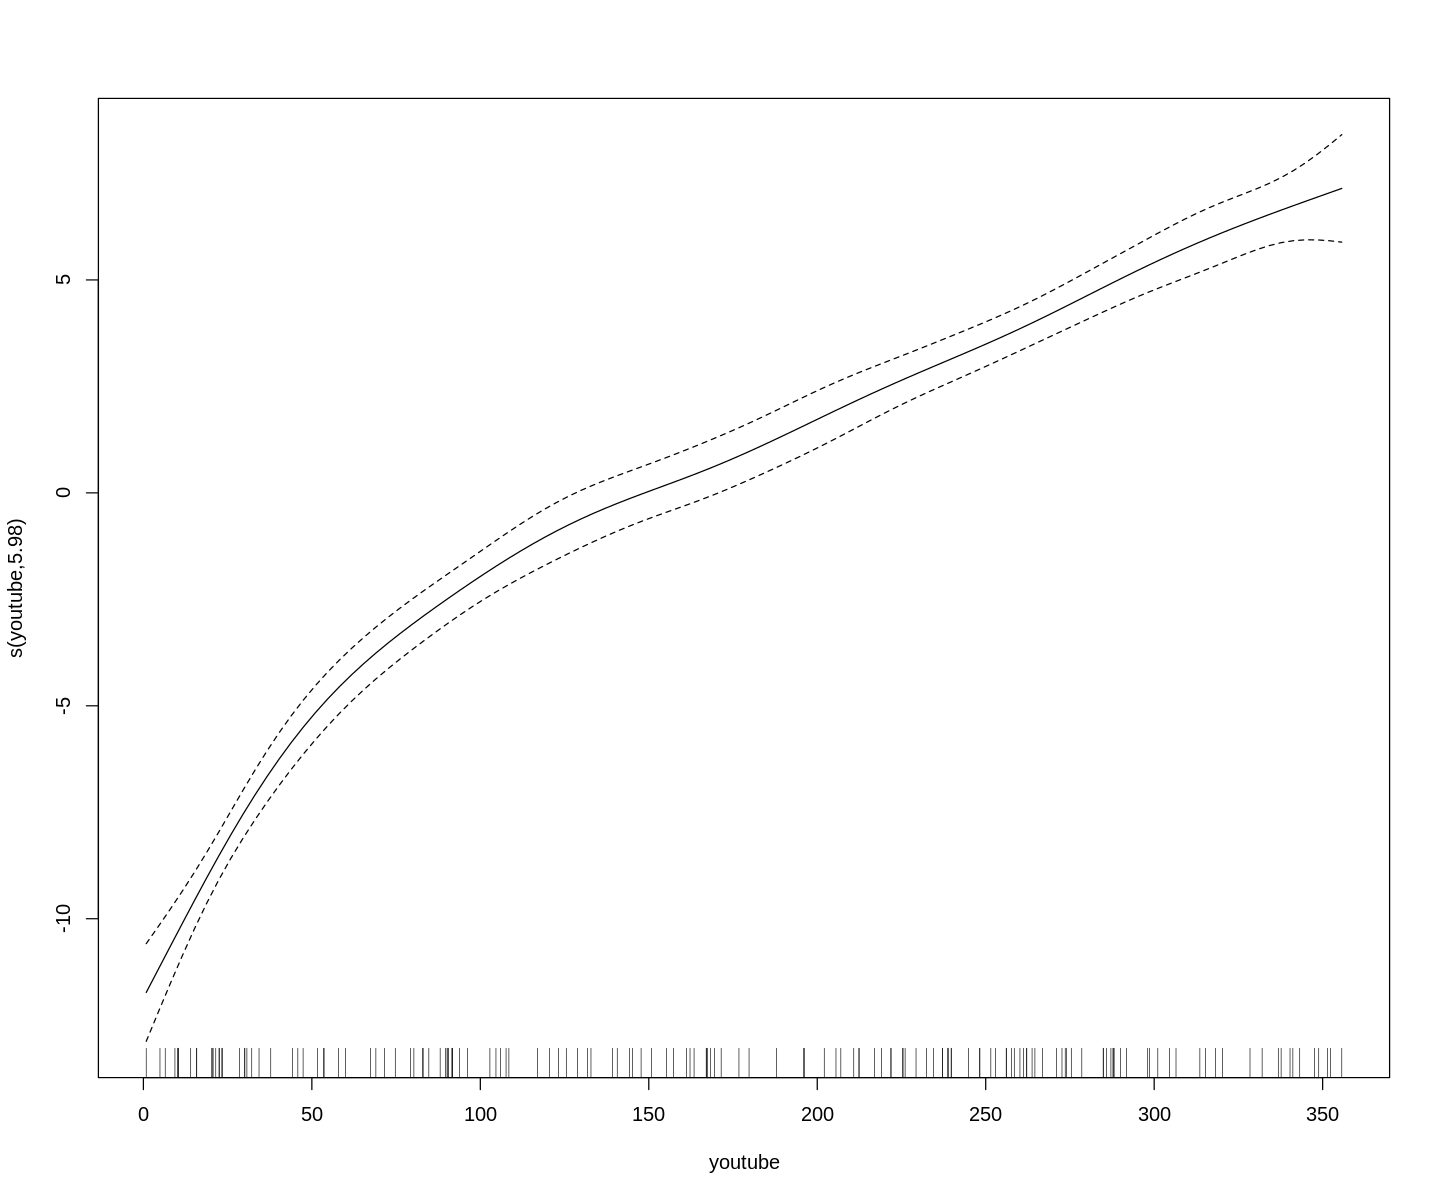

In [154]:
plot(semiparametric_marketing)

**2.(c) Model comparisons**

Now, let's do some model comparisons on the test data. Compute the mean squared prediction error (MSPE) on the `test_marketing` data for the following three models:

- `gam_marketing` from 2.(a)


- `semiparametric_marketing`from 2.(b)


- `lm_marketing`, a linear regression model with `sales` is the response and `youtube` and `facebook` are predictors (fit on the `train_marketing` data).

State which model performs based according to this metric.

### Answer:

Again, computing the **MSPE** for the models on the **test** data, we conclude that the **semiparametric** model predorms the best (with the lowest test **MSPE** value $=3.297448$, which is slightly lower than **GAM** model's test **MSPE**).

In [157]:
lm_marketing = lm(sales ~ youtube + facebook, data = train_marketing)
summary(lm_marketing)

#mspe for gam
mspe_gam = mean((test_marketing$sales - predict(gam_marketing, newdata=test_marketing, type = "response"))^2)

#mspe for semiparametric
mspe_semiparametric = mean((test_marketing$sales - predict(semiparametric_marketing, newdata=test_marketing, type = "response"))^2)

# mspe for lm
mspe_lm = mean((test_marketing$sales - predict(lm_marketing, newdata=test_marketing))^2)

data.frame(mspe_gam, mspe_semiparametric, mspe_lm)


Call:
lm(formula = sales ~ youtube + facebook, data = train_marketing)

Residuals:
     Min       1Q   Median       3Q      Max 
-10.1914  -0.9730   0.3786   1.4414   3.2354 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 3.617054   0.390963   9.252   <2e-16 ***
youtube     0.046430   0.001522  30.500   <2e-16 ***
facebook    0.177932   0.009302  19.129   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.022 on 157 degrees of freedom
Multiple R-squared:  0.8973,	Adjusted R-squared:  0.896 
F-statistic:   686 on 2 and 157 DF,  p-value: < 2.2e-16


mspe_gam,mspe_semiparametric,mspe_lm
<dbl>,<dbl>,<dbl>
3.409949,3.297448,4.197701
